## 1. Introduction

The Titanic dataset is one of the most well-known datasets in data science and machine learning. It contains details of passengers aboard the RMS Titanic and their survival status. This notebook builds a simple neural network model to predict whether a passenger survived, based on the available features.

## 2. Problem Statement

The objective is to classify passengers as either survivors or non-survivors using a neural network. We will preprocess the data, train a neural network, and evaluate its performance using standard classification metrics.

In [50]:
# ==============================
# Install packages (Colab)
# ==============================
!pip -q install openpyxl tensorflow

# ==============================
# Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc,
                              ConfusionMatrixDisplay)



import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



In [19]:
# Upload Titanic Excel file
# uploaded = files.upload()

# # Read the uploaded file
# filename = list(uploaded.keys())[0]
# df = pd.read_excel(filename)

# print("Dataset Shape:", df.shape)
# df.head()
filename="/content/titanic.xlsx"

# Read Excel file
df = pd.read_excel(filename)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


## 4. Data Preprocessing

We'll go through the standard steps in order:

1. **Handling missing values** — impute `Age` and `Embarked`, drop `Cabin` (too many missing values).
2. **Dropping irrelevant columns** — `PassengerId`, `Name`, `Ticket` don't carry predictive signal in raw form.
3. **Encoding categorical data** — convert `Sex` and `Embarked` to numeric.
4. **Feature scaling** — standardize numeric features so the network trains well.
5. **Splitting data** — into train and test sets.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nSurvival rate:")
print(df['Survived'].value_counts(normalize=True))

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival rate:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [22]:

# Drop unnecessary columns

drop_cols = ["PassengerId","Name","Ticket","Cabin"]

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Fill Missing Values

if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


# Convert categorical variables

# df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
# df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns found:", categorical_cols)

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Categorical columns found: ['Sex', 'Embarked']


In [24]:
df.head(5)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [41]:
# 4.4 Split features/target, then train/test split
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4.5 Feature scaling (fit on train only, apply to both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (712, 8)
Test shape: (179, 8)


## 5. Model Implementation

### Architecture
* **Input layer:** one node per feature
* **Hidden layers:** Dense layers with ReLU activation
* **Output layer:** single node with sigmoid activation (binary classification)

### Compilation
* **Loss:** binary cross-entropy
* **Optimizer:** Adam
* **Metric:** accuracy

In [42]:
# Define the neural network architecture
n_features = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Train the model, monitoring validation performance to avoid overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6081 - loss: 0.6727 - val_accuracy: 0.6224 - val_loss: 0.6509
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6643 - loss: 0.6432 - val_accuracy: 0.6643 - val_loss: 0.6170
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6766 - loss: 0.6136 - val_accuracy: 0.6783 - val_loss: 0.5892
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7118 - loss: 0.5854 - val_accuracy: 0.7203 - val_loss: 0.5653
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7241 - loss: 0.5707 - val_accuracy: 0.7483 - val_loss: 0.5445
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7417 - loss: 0.5569 - val_accuracy: 0.7762 - val_loss: 0.5258
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7592 - loss: 0.5351 - val_accuracy: 0.7762 - val_loss: 0.5103
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7522 - loss: 0.5304 - val_accuracy: 0.7902 -

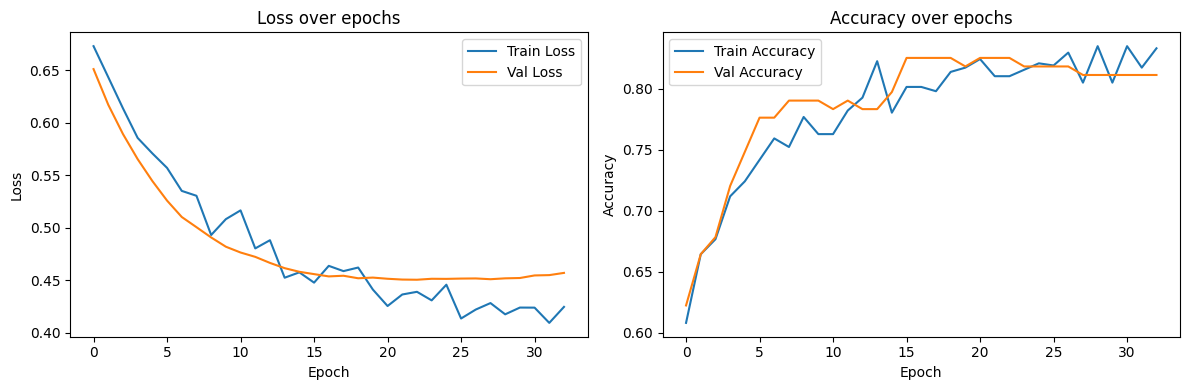

In [47]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Model Evaluation

We assess performance on the held-out test set using accuracy, precision, recall, F1-score, a confusion matrix, and the ROC curve.

In [48]:
# Predictions on the test set
y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Accuracy:  0.8101
Precision: 0.8571
Recall:    0.6087
F1-score:  0.7119


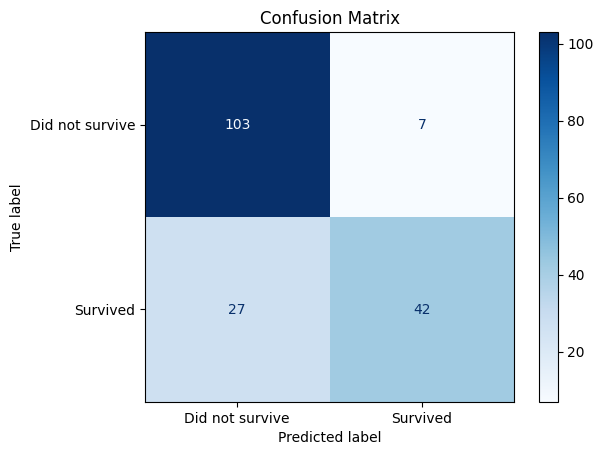

In [51]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

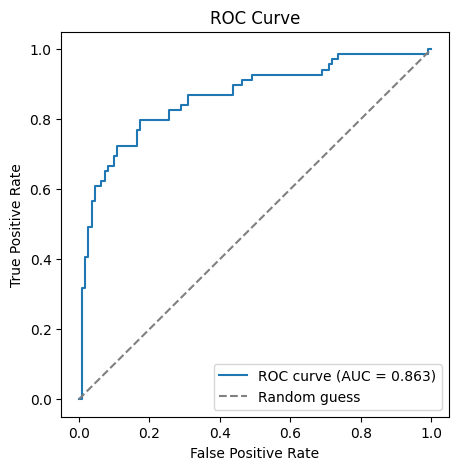

In [52]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 7. Conclusion

**Key findings** *(fill in with your actual numbers after running the notebook)*:
- The model achieved an accuracy of **~81%**, precision of **~85%**, recall of **~60%**, and an F1-score of **~71%** on the test set.
- The ROC-AUC of **~86%** indicates the model's ability to separate survivors from non-survivors.
- Sex and passenger class tend to be strong predictors of survival on this dataset (women and first-class passengers had notably higher survival rates).

**Potential improvements:**
- **Hyperparameter tuning** — try different numbers of layers/neurons, learning rates, batch sizes, and dropout rates (e.g., via `keras_tuner` or grid search).
- **Feature engineering** — extract titles from `Name` (Mr., Mrs., Miss, etc.), create a `FamilySize` feature from `SibSp` + `Parch`, or bin `Age`/`Fare`.
- **Handling class imbalance** — use class weights if survival classes are imbalanced.
- **More complex architectures** — deeper networks, batch normalization, or ensembling with tree-based models (Random Forest, XGBoost) for comparison.
- **Cross-validation** — use k-fold cross-validation instead of a single train/test split for a more robust performance estimate.